# **Notebook 2a: Preparing hand labeled dataset**

## 1. Importing the packages

In [ ]:
# Loading the packages
import re
import nltk
import numpy as np
import pandas as pd
from nltk.data import load
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import sent_tokenize
from nltk.tokenize import PunktSentenceTokenizer
from nltk.tokenize.punkt import PunktParameters
from sklearn.model_selection import train_test_split

nltk.download("punkt_tab")
tqdm.pandas()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Individual thesis part/Data preparation")
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/Individual thesis part/Data preparation


## 2. Loading the dataset

In [ ]:
# Loading the dataset
data = pd.read_csv("dataset_cleaned.tsv", sep="\t", on_bad_lines="warn", low_memory=False)

# Only keeping rows with non-null blurb and final_edit
useful_data = data.dropna(subset=["blurb", "final_edit"]).copy()
n_after_dropna = len(useful_data)

# Dropping exact duplicates on (blurb, final_edit), keeping the first occurrence
useful_data = useful_data.drop_duplicates(subset=["blurb", "final_edit"]).reset_index(drop=True)
n_after_dedup = len(useful_data)

# Reporting
print(f"Original rows:                  {len(data):,}")
print(f"After dropping NaN blurb/edit:  {n_after_dropna:,}")
print(f"After dropping duplicates:      {n_after_dedup:,}")
print(f"Removed as duplicates:          {n_after_dropna - n_after_dedup:,}")

Original rows:                  25,917
After dropping NaN blurb/edit:  24,900
After dropping duplicates:      24,890
Removed as duplicates:          10


In [ ]:
# Adding a blurb index to the dataset to later be able to get all variables back to each individual blurb
useful_data["blurb_id"] = useful_data.index

## 3. Looking into words in the data that end with an dot to find abbreviations to add to the tokanizer to make it split sentences better.

In [ ]:
# Looking into original abbreviations build in the tokanizer

from nltk.data import load
# Loading NLTK's Dutch Punkt tokenizer
dutch_punkt = load("tokenizers/punkt/PY3/dutch.pickle")
known_abbreviations = dutch_punkt._params.abbrev_types

print(f"NLTK knows {len(known_abbreviations)} dutch abbreviations\n")

# Sort and print
for abbr in sorted(known_abbreviations):
    print(f"  {abbr}.")

NLTK knows 99 dutch abbreviations

  a.
  a.l.
  a.m.
  a.s.
  a.v.
  a.v.d.
  aansluit.
  aanvielen.
  b.b.
  b.v.
  bijgebracht.
  binnengekomen.
  blz.
  bod.
  c.
  c.c.
  c.j.
  c.p.j.
  c.q.
  chr.
  dr.
  drs.
  ds.
  e.
  e.d.
  e.l.
  esb.
  f.c.
  f.m.
  f.o.j.
  f.v.d.
  fr.
  g.
  gesch.
  h.
  h.g.
  h.p.
  h.s.
  inc.
  ing.
  int.
  ir.
  j.
  j.a.
  j.b.m.
  j.d.
  j.f.
  j.g.
  j.h.
  j.l.
  j.m.
  j.v.d.
  j.w.
  jl.
  jr.
  k.
  l.
  l.a.
  l.e.h.
  m.
  m.b.
  m.g.
  m.i.v.
  m.j.
  m.o.
  m.v.d.
  mgr.
  mm.
  mr.
  n.
  nr.
  o.a.
  o.m.
  ontwaakte.
  p.
  p.a.m.
  p.f.
  p.j.
  pensioenfonds.
  ph.
  pk.
  r.
  r.p.
  r.v.d.
  s.
  s.v.
  s.v.p.
  s.z.
  schouwburg.
  st.
  t.
  t.e.
  th.
  u.o.m.
  v.
  v.d.
  v.l.n.r.
  w.k.
  y.


In [ ]:
# Looking into abbreviations in the blurbs and final_edits

copy = useful_data.copy()
all_text = " ".join(copy["blurb"].astype(str)) + " " + " ".join(copy["final_edit"].astype(str))
# Counting words followed by period + space (where tokenizer might split)
words_with_dot = Counter(
    m.lower() for m in re.findall(r"\b([a-zA-Zé]{1,6})\.\s", all_text))

# Counting all word occurrences (single pass)
all_words = Counter(w.lower() for w in re.findall(r"\b[a-zA-Zé]{1,10}\b", all_text))

# Building table
rows = []
for word, count in words_with_dot.items():
    if count < 5:
        continue
    total = all_words.get(word, count)
    pct = count / total * 100 if total else 0
    if pct > 70: # Only show words that appear more then 70% with a dot after it (making more sure it is indeed a abbreviations)
        rows.append({
            "word": word,
            "length": len(word),
            "count": count,
            "pct_with_period": round(pct, 1),})

df = (pd.DataFrame(rows)
    .sort_values(["length", "count"], ascending=[True, False])
    .reset_index(drop=True))

# Showing all rows, grouped by word length
print(f"Total candidates: {len(df)}\n")

for length in sorted(df["length"].unique()):
    subset = df[df["length"] == length]
    print(f"=== {length} letters ({len(subset)} candidates) ===")
    print(subset[["word", "count", "pct_with_period"]].to_string(index=False))
    print()

Total candidates: 38

=== 2 letters (7 candidates) ===
word  count  pct_with_period
  ca   6801             99.5
  dr    771             94.5
  mr    133             88.1
  st    115             70.1
  ds     28             80.0
  ir     21             84.0
  sr      7             87.5

=== 3 letters (8 candidates) ===
word  count  pct_with_period
 drs     81             97.6
 etc     42             71.2
 inc     21             80.8
 pag     12            100.0
 mgr      8            100.0
 ind      8             72.7
 iss      6             75.0
 dhr      5            100.0

=== 4 letters (8 candidates) ===
word  count  pct_with_period
prof    192             90.6
gebr     12            100.0
zoen      9             81.8
bijv      8            100.0
bros      6             85.7
chin      6             85.7
fame      6             75.0
muys      5            100.0

=== 5 letters (7 candidates) ===
 word  count  pct_with_period
subsp     28            100.0
skull     12             85.7

In [ ]:
# Initial check (also other words with a dot after every letter)

all_combos_by_length = {}

for length in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
    pattern = r"\b(" + r"\.".join(["[A-Z]"] * length) + r")\.\s"
    combos = re.findall(pattern, all_text)
    counts = Counter(c.lower() for c in combos)
    all_combos_by_length[length] = counts

    print(f"\nTop {length}-letter combinations ({len(counts)} unique):")
    for combo, count in counts.most_common(10):
        marker = "+" if combo in known_abbreviations else "x"
        print(f"  {marker} {combo}.: {count}")


Top 2-letter combinations (210 unique):
  + m.j.: 64
  + m.g.: 61
  x r.r.: 58
  x p.c.: 56
  + j.d.: 46
  + f.c.: 40
  + j.m.: 35
  x j.j.: 32
  x c.s.: 30
  x j.c.: 28

Top 3-letter combinations (69 unique):
  x j.r.r.: 35
  x j.m.a.: 20
  x c.c.s.: 11
  x w.e.b.: 10
  x b.i.g.: 6
  x e.l.d.: 6
  x c.m.m.: 5
  x a.h.j.: 5
  x i.s.s.: 5
  x h.t.m.: 5

Top 4-letter combinations (14 unique):
  x i.e.l.d.: 6
  x c.u.r.e.: 3
  x h.w.j.m.: 3
  x n.e.u.s.: 2
  x p.o.o.k.: 2
  x s.m.a.k.: 2
  x r.a.i.n.: 2
  x k.n.w.u.: 2
  x a.g.i.k.: 1
  x g.o.a.t.: 1

Top 5-letter combinations (6 unique):
  x h.i.e.l.d.: 6
  x r.n.e.u.s.: 2
  x s.p.o.o.k.: 2
  x b.r.a.i.n.: 2
  x m.a.g.i.k.: 1
  x i.a.r.t.y.: 1

Top 6-letter combinations (3 unique):
  x s.h.i.e.l.d.: 6
  x u.r.n.e.u.s.: 2
  x r.i.a.r.t.y.: 1

Top 7-letter combinations (2 unique):
  x e.u.r.n.e.u.s.: 2
  x o.r.i.a.r.t.y.: 1

Top 8-letter combinations (2 unique):
  x p.e.u.r.n.e.u.s.: 2
  x m.o.r.i.a.r.t.y.: 1

Top 9-letter combinations (1

In [ ]:
# Finetuning the tokenizer, to optimize sentence splitting

# 1. Loading NLTK's default Dutch abbreviations
dutch_punkt = load("tokenizers/punkt/PY3/dutch.pickle")
default_abbreviations = dutch_punkt._params.abbrev_types
print(f"NLTK default: {len(default_abbreviations)} abbreviations")

# 2. Removing items that are clearly not abbreviations (just normal Dutch words)
clearly_not_abbreviations = {
    "aansluit", "aanvielen", "bijgebracht", "binnengekomen",
    "bod", "ontwaakte", "pensioenfonds", "schouwburg",}

# 3. Defining additions found in the data
extra_abbreviations = {
    "ca", "dr", "mr", "st", "ds", "ir", "sr",
    "drs", "etc", "inc", "pag", "mgr", "ind", "dhr",
    "prof", "gebr", "bijv", "bros", "chin", "subsp",}

# 4. Auto-detecting initial combinations from the data (length 2-10)
# or other long lines of letters with dots in between --> important that the tokanizer does not split on these to create as good sentence splits as possible.
data_initial_combos = set()
for length in range(2, 11):
    pattern = r"\b(" + r"\.".join(["[A-Z]"] * length) + r")\.\s"
    for m in re.findall(pattern, all_text):
        data_initial_combos.add(m.lower())

new_data_combos = data_initial_combos - default_abbreviations

# 5. Building the final set of abbrevations
final_abbreviations = (
    (default_abbreviations - clearly_not_abbreviations)
    | extra_abbreviations
    | new_data_combos)

# 6. Building custom tokenizer
punkt_params = PunktParameters()
punkt_params.abbrev_types = final_abbreviations
custom_tokenizer = PunktSentenceTokenizer(punkt_params)

# Summary of the taken steps
print(f"\nRemoved: {len(clearly_not_abbreviations)} mistaken entries from NLTK default")
print(f"Added:   {len(extra_abbreviations)} domain-specific abbreviations")
print(f"Added:   {len(new_data_combos)} (probable) initial combinations from data")
print(f"Final:   {len(final_abbreviations)} abbreviations")

NLTK default: 99 abbreviations

Removed: 8 mistaken entries from NLTK default
Added:   20 domain-specific abbreviations
Added:   279 (probable) initial combinations from data
Final:   382 abbreviations


## 4. Doing an extra data cleaning looking into the two main variables used for the research (final_edit and blurb)

### 4.1 Looking into the blurbs

In [ ]:
# Tokenizing blurbs using the custom tokenizer
copy["blurb_sent"] = copy["blurb"].apply(lambda x: custom_tokenizer.tokenize(str(x))) # use custom tokanizer
copy["blurb_sent_len"] = copy["blurb_sent"].apply(len)

# Looking into the amount of sentences
print(copy["blurb_sent_len"].describe())

count    24890.000000
mean         9.608839
std          9.007806
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max       1193.000000
Name: blurb_sent_len, dtype: float64


In [ ]:
copy["blurb_sent_len"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.996, 0.997, 0.998, 0.999, 0.9999])

,blurb_sent_len
count,24890.000000
mean,9.608839
std,9.007806
min,1.000000
50%,9.000000
75%,12.000000
90%,15.000000
95%,18.000000
99%,25.000000
99.5%,28.000000


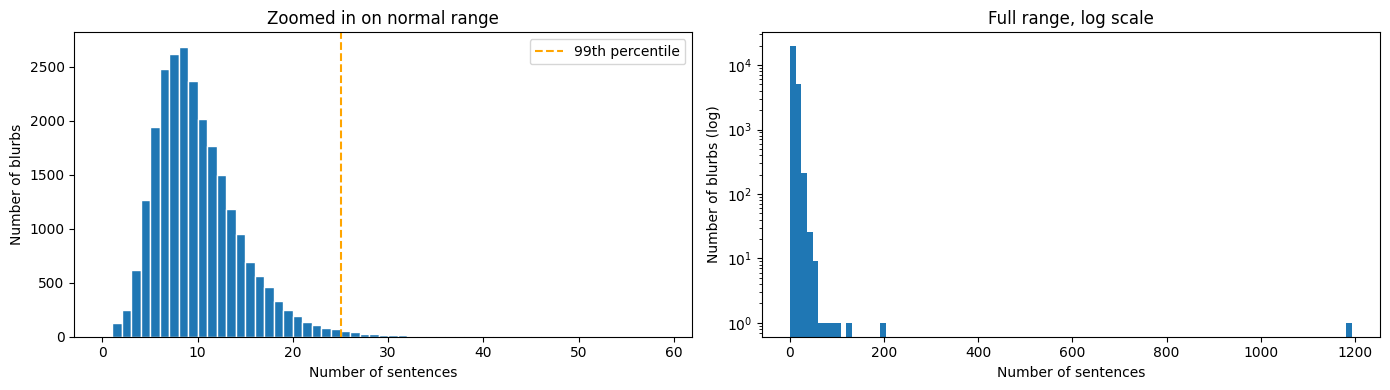

In [ ]:
# Showing histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear, zoomed in on normal range
axes[0].hist(copy["blurb_sent_len"], bins=range(0, 60), edgecolor="white")
axes[0].axvline(25, color="orange", linestyle="--", label="99th percentile")
axes[0].set_xlabel("Number of sentences")
axes[0].set_ylabel("Number of blurbs")
axes[0].set_title("Zoomed in on normal range")
axes[0].legend()

# Full range, log y-axis
axes[1].hist(copy["blurb_sent_len"], bins=100)
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of sentences")
axes[1].set_ylabel("Number of blurbs (log)")
axes[1].set_title("Full range, log scale")

plt.tight_layout()
plt.show()

In [ ]:
for drempel in [25, 30, 35, 40, 50, 75, 100]:
    aantal = (copy["blurb_sent_len"] > drempel).sum()
    pct = aantal / len(copy) * 100
    print(f"> {drempel:>3} sentences: {aantal:>4} blurbs ({pct:.3f}%)")

>  25 sentences:  203 blurbs (0.816%)
>  30 sentences:   86 blurbs (0.346%)
>  35 sentences:   46 blurbs (0.185%)
>  40 sentences:   26 blurbs (0.104%)
>  50 sentences:   14 blurbs (0.056%)
>  75 sentences:    5 blurbs (0.020%)
> 100 sentences:    4 blurbs (0.016%)


In [ ]:
"""
extreme = copy[copy["blurb_sent_len"] > 50]

with open("blurb_inspection.txt", "w", encoding="utf-8") as f:
    for _, row in extreme.iterrows():
        f.write(f"\n{'='*70}\n")
        f.write(f"blurb_sent_len: {row['blurb_sent_len']}\n")
        f.write(f"{'='*70}\n\n")
        for i, sent in enumerate(row["blurb_sent"]):
            f.write(f"{i}: {sent}\n")

print("Written to blurb_inspection.txt — open and read")
"""

'\nextreme = copy[copy["blurb_sent_len"] > 50]\n\nwith open("blurb_inspection.txt", "w", encoding="utf-8") as f:\n    for _, row in extreme.iterrows():\n        f.write(f"\n{\'=\'*70}\n")\n        f.write(f"blurb_sent_len: {row[\'blurb_sent_len\']}\n")\n        f.write(f"{\'=\'*70}\n\n")\n        for i, sent in enumerate(row["blurb_sent"]):\n            f.write(f"{i}: {sent}\n")\n\nprint("Written to blurb_inspection.txt — open and read")\n'

Based on the observations in the txt with the blurbs with the highest amount of sentences we decided to filter out all blurbs with more 56 sentences. (10 rows were filtered out.)

In [ ]:
# Collecting IDs of blurbs to remove (above threshold)
threshold = 56
ids_to_remove = copy[copy["blurb_sent_len"] > threshold]["blurb_id"].tolist()

print(f"\nNumber of blurbs to remove: {len(ids_to_remove)}")
print(f"First 10 IDs: {ids_to_remove[:10]}")


Number of blurbs to remove: 10
First 10 IDs: [4222, 5258, 5596, 6447, 6823, 8790, 12980, 16415, 19635, 22367]


### 4.2 Looking into the final edits

In [ ]:
# Tokenizing blurbs using the custom tokenizer
copy["edit_sent"] = copy["final_edit"].apply(lambda x: custom_tokenizer.tokenize(str(x)))
copy["edit_sent_len"] = copy["edit_sent"].apply(len)

# Looking into the amount of sentences
print(copy["edit_sent_len"].describe())

count    24890.000000
mean         9.000884
std          2.189540
min          1.000000
25%          8.000000
50%          9.000000
75%         10.000000
max         19.000000
Name: edit_sent_len, dtype: float64


/tmp/ipykernel_4621/2818641411.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


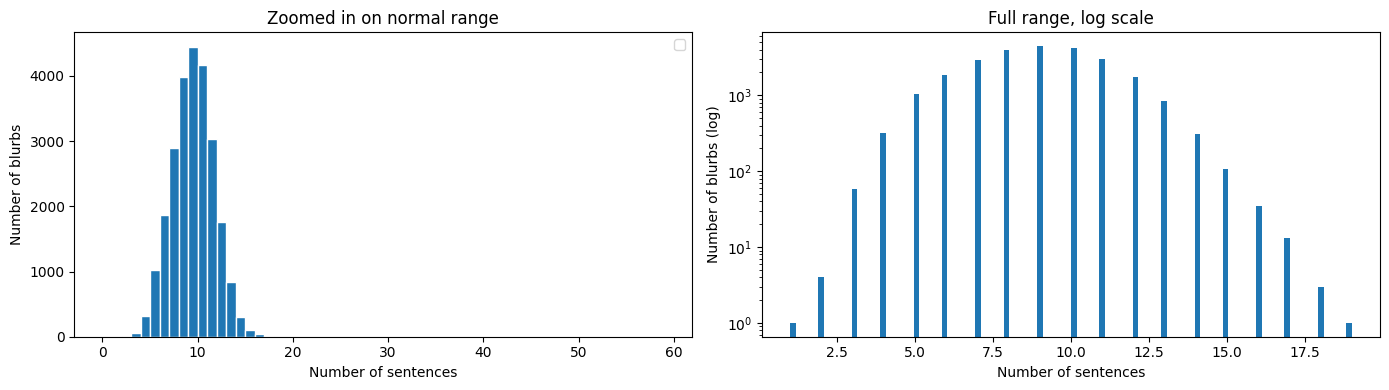

In [ ]:
# Showing histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear, zoomed in on normal range
axes[0].hist(copy["edit_sent_len"], bins=range(0, 60), edgecolor="white")
axes[0].set_xlabel("Number of sentences")
axes[0].set_ylabel("Number of blurbs")
axes[0].set_title("Zoomed in on normal range")
axes[0].legend()

# Full range, log y-axis
axes[1].hist(copy["edit_sent_len"], bins=100)
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of sentences")
axes[1].set_ylabel("Number of blurbs (log)")
axes[1].set_title("Full range, log scale")

plt.tight_layout()
plt.show()

 Looks like a perfect normal distribution, no signs to expect unusefull final_edits. This could be explained by the fact that final_edit is always checked by a human ones while blurbs in some cases seem to be scraped from the back of a book using a scrapping program.

### 3.3 Saving the filtered dataset

In [ ]:
# Deleting the rows with outlier blurbs
useful_data = useful_data[~useful_data["blurb_id"].isin(ids_to_remove)].copy() # Deleting the id's with long blurbs (outliers)
useful_data.reset_index(drop=True, inplace=True)
useful_data["blurb_id"] = range(len(useful_data)) # Resetting the blurb_id

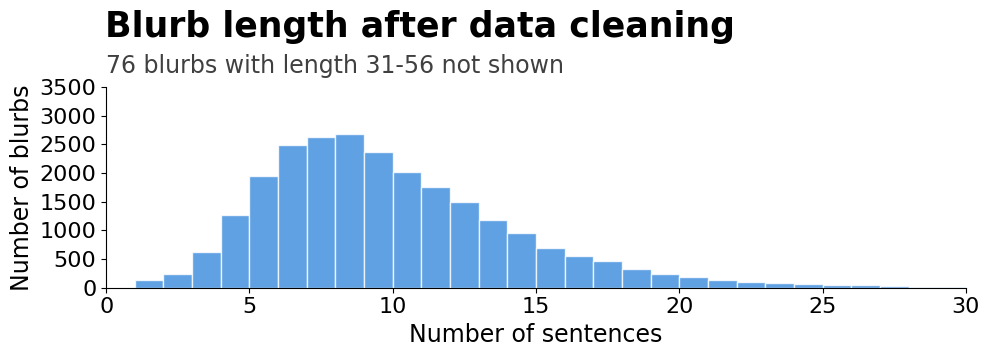

In [ ]:
# Making sentence distributions plot of the blurbs
copy2["blurb_sent"] = copy2["blurb"].apply(lambda x: custom_tokenizer.tokenize(str(x)))
copy2["blurb_sent_len"] = copy2["blurb_sent"].apply(len)

# Histogram blurb len after deleting long blurbs (>56)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(copy2["blurb_sent_len"], bins=range(0, 60), edgecolor="white", color="#378ADD", alpha=0.8)
ax.set_xlim(0, 30)
n_tail = (copy2["blurb_sent_len"] > 40).sum()
max_val = copy2["blurb_sent_len"].max()
fig.suptitle("Blurb length after data cleaning", fontsize=25, fontweight="bold", x=0.11, y=0.88, ha="left")
ax.set_title(f"76 blurbs with length 31-56 not shown",
              fontsize=17, color="#404040", loc="left", pad=10)
ax.set_xlabel("Number of sentences", fontsize=17)
ax.set_ylabel("Number of blurbs", fontsize=17)
ax.tick_params(axis="both", labelsize=16)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout(rect=[0, 0, 1, 0.93])
ax.set_yticks([0, 500, 1000, 1500, 2000, 2500, 3000, 3500])
plt.show()

In [ ]:
# Saving preparated dataset with blurb id
useful_data.to_csv("dataset_cleaned_blurb_id.tsv", sep="\t", index=False)

## 5. Creating dataset to label by hand

In [ ]:
# Loading the dataset
data_clean = pd.read_csv("dataset_cleaned_blurb_id.tsv", sep="\t", on_bad_lines="warn", low_memory=False)

In [ ]:
# Randomly sampling 200 rows (blurbs) and save their indices
handlabeled_indices = data_clean.sample(n=200, random_state=250).index

# Putting the sampled rows (blurbs) in a new DataFrame
data_to_hand_label = data_clean.loc[handlabeled_indices].reset_index(drop=True)

# Removing those rows from the original DataFrame
data_unlabeled = data_clean.drop(index=handlabeled_indices).reset_index(drop=True)

print(f"Rows (blurbs) in handlabeled dataset:   {len(data_to_hand_label)}")
print(f"Rows (blurbs) in unlabeled dataset: {len(data_unlabeled)}")

Rows in handlabeled_df:   200
Rows remaining in analysis_df_all: 24680


In [ ]:
# Building a per-sentence test and development (train and validation) set with blurb ID and sentence position
data_to_hand_label_sent = data_to_hand_label.copy()
data_to_hand_label_sent["blurb_sent"] = data_to_hand_label_sent["blurb"].apply(lambda x: custom_tokenizer.tokenize(str(x)))
data_to_hand_label_sent = data_to_hand_label_sent[["blurb_id", "blurb", "final_edit", "blurb_sent"]].explode("blurb_sent")
data_to_hand_label_sent["sent_position"] = data_to_hand_label_sent.groupby("blurb_id").cumcount()
data_to_hand_label_sent["unnecessary"] = None
data_to_hand_label_sent = data_to_hand_label_sent.reset_index(drop=True)

# Checks
print(f"Total sentences: {len(data_to_hand_label_sent)}")
print(f"Unique blurbs: {data_to_hand_label_sent['blurb_id'].nunique()}")
print(data_to_hand_label_sent.head(20))

#------------------------------------------------------------------------------------------
# Output deactivated for data privacy concerns

## 5. Putting the train data in the same format as the validation/test data

In [ ]:
# Building per-sentence training data with blurb ID and sentence position
data_unlabeled_sent = data_unlabeled.copy()
data_unlabeled_sent["blurb_sent"] = data_unlabeled_sent["blurb"].apply(lambda x: custom_tokenizer.tokenize(str(x)))
data_unlabeled_sent = data_unlabeled_sent[["blurb_id", "blurb", "final_edit", "blurb_sent"]].explode("blurb_sent")
data_unlabeled_sent["sent_position"] = data_unlabeled_sent.groupby("blurb_id").cumcount()
data_unlabeled_sent["unnecessary"] = None
data_unlabeled_sent = data_unlabeled_sent.reset_index(drop=True)

# Checks
print(f"Total sentences: {len(data_unlabeled_sent)}")
print(f"Unique blurbs: {data_unlabeled_sent['blurb_id'].nunique()}")
print(data_unlabeled_sent.head(20))

#------------------------------------------------------------------------------------------
# Output deactivated for data privacy concerns

## 6. Saving the files as xlsx

In [ ]:
# Saving
data_unlabeled_sent.to_csv("unlabeled_data.tsv", sep="\t", index=False)
data_to_hand_label_sent.to_excel("labeled_data.xlsx", index=False)